In [6]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parent))
from pathlib import Path
import json
import pandas as pd
import numpy as np
def load_direct_data(en, cont, alg, name):
    path = f"../Data/generation_ex/{en}/{cont}/{alg}/{name}"
    json_files = list(Path(path).glob("*.json"))
    print(f"Found {len(json_files)} files!")
    with open(json_files[0], "r", encoding="utf-8") as f:
        data = json.load(f)
    return data

def extract_fitness_values(file_content):
    df = pd.DataFrame(file_content["fitness"]).reset_index(names="seed").melt(
        id_vars="seed", 
        var_name="ng", 
        value_name="population"
    )
    df["ng"] = df["ng"].astype(int)
    df["max_fit"] = df["population"].apply(lambda x: np.max(list(map(lambda y: y[0], x))))
    df["avg_fit"] = df["population"].apply(lambda x: np.mean(list(map(lambda y: y[0], x))))
    df["median_fit"] = df["population"].apply(lambda x: np.median(list(map(lambda y: y[0], x))))
    df["min_fit"] = df["population"].apply(lambda x: np.min(list(map(lambda y: y[0], x))))
    df["std_fit"] = df["population"].apply(lambda x: np.std(list(map(lambda y: y[0], x))))
    return df
def save_final_hyperparameters(en, cont, alg, hyper_paramters):
    
    with open("../relevant_finals.json", "r+", encoding="utf-8") as f:
        try:
            data = json.load(f)
        except json.JSONDecodeError:
            data = {}
        print(type(data))
        f.seek(0)       
        if cont not in data:
            data[cont] = {}
        if en not in data[cont]:
            data[cont][en] = {}
        data[cont][en][alg] = hyper_paramters
        json.dump(data, f, indent=4)
        f.truncate()
    print(f"Just saved {','.join([cont, en, alg])}")

def get_decided():
    with open("../relevant_finals.json", "r", encoding="utf-8") as f:
        data = json.load(f)
        df = pd.json_normalize(data)
    return np.unique(list(map(lambda x: ".".join(x.split(".")[0:3]), df.columns)))


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
location = {"cartpole": "server_try0", "lunarlander":"server_try3"}
def plot_decision_chart(en, alg, cont, ax=None):
    file_content = load_direct_data(en, cont, alg, location[en])
    df = extract_fitness_values(file_content)
    df = df.sort_values("ng")
    ploted_df = df[["ng", "seed", "max_fit", "median_fit", "avg_fit"]]
    if "seed" in ploted_df.columns:
        ploted_df = ploted_df.drop(columns="seed")
    ploted_df = ploted_df.melt(
            id_vars="ng", 
            var_name="type", 
            value_name="value"
        )
    return sns.lineplot(data=ploted_df, x="ng", y="value", hue="type", ax=ax)


Found 1 files!


<Axes: xlabel='ng', ylabel='value'>

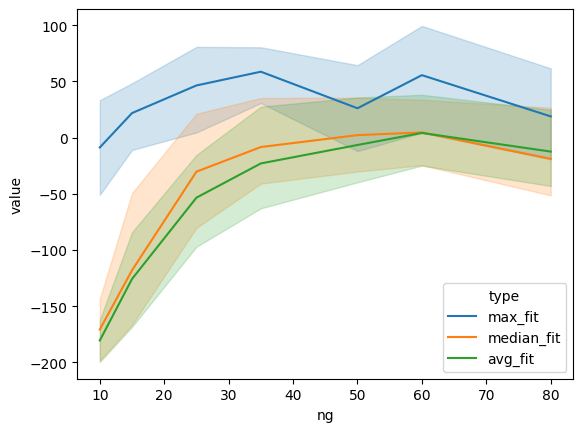

In [8]:
en = "lunarlander"
alg = "diff"
cont = "elite_archiving"
plot_decision_chart(en,alg,cont)

Found 1 files!
fitness
Found 1 files!
fitness
Found 1 files!
novelty
Found 1 files!
novelty
Found 1 files!
add_novelty
Found 1 files!
add_novelty
Found 1 files!
sub_novelty
Found 1 files!
sub_novelty
Found 1 files!
fit_archiving
Found 1 files!
fit_archiving
Found 1 files!
elite_archiving
Found 1 files!
elite_archiving
Found 1 files!
novelty_archiving
Found 1 files!
novelty_archiving
Found 1 files!
novelty_limit
Found 1 files!
novelty_limit
Found 1 files!
fitness
Found 1 files!
fitness
Found 1 files!
novelty
Found 1 files!
novelty
Found 1 files!
add_novelty
Found 1 files!
add_novelty
Found 1 files!
sub_novelty
Found 1 files!
sub_novelty
Found 1 files!
fit_archiving
Found 1 files!
fit_archiving
Found 1 files!
elite_archiving
Found 1 files!
elite_archiving
Found 1 files!
novelty_archiving
Found 1 files!
novelty_archiving
Found 1 files!
novelty_limit
Found 1 files!
novelty_limit


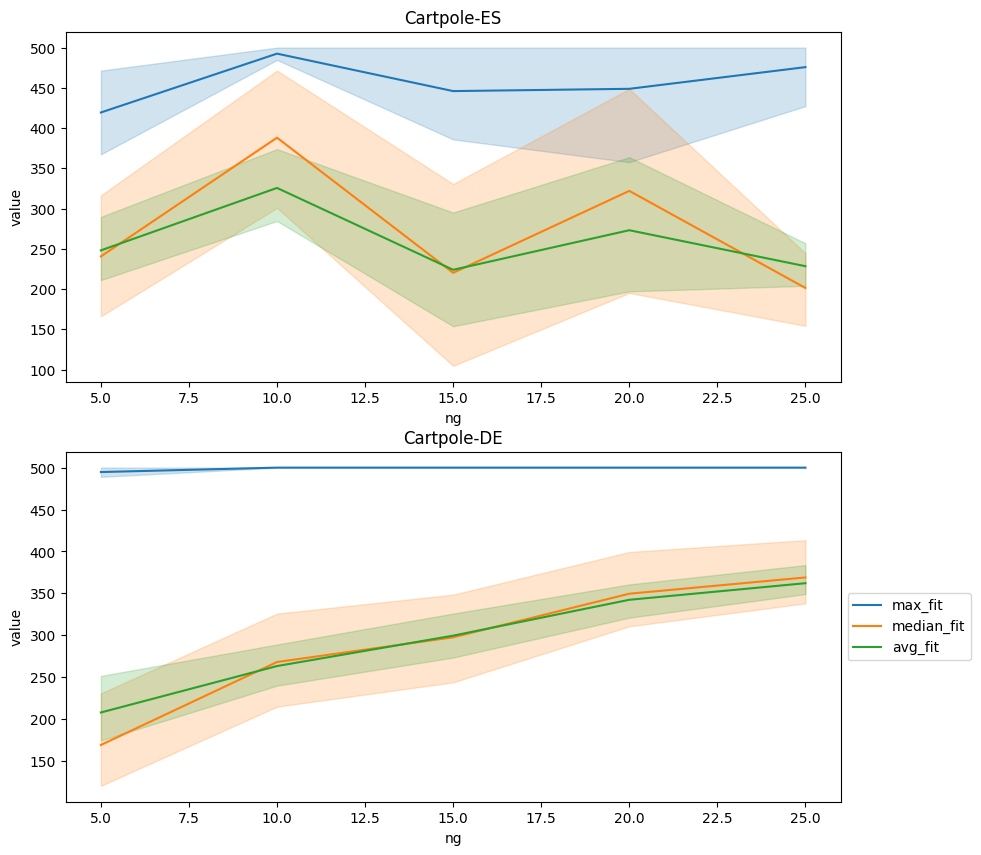

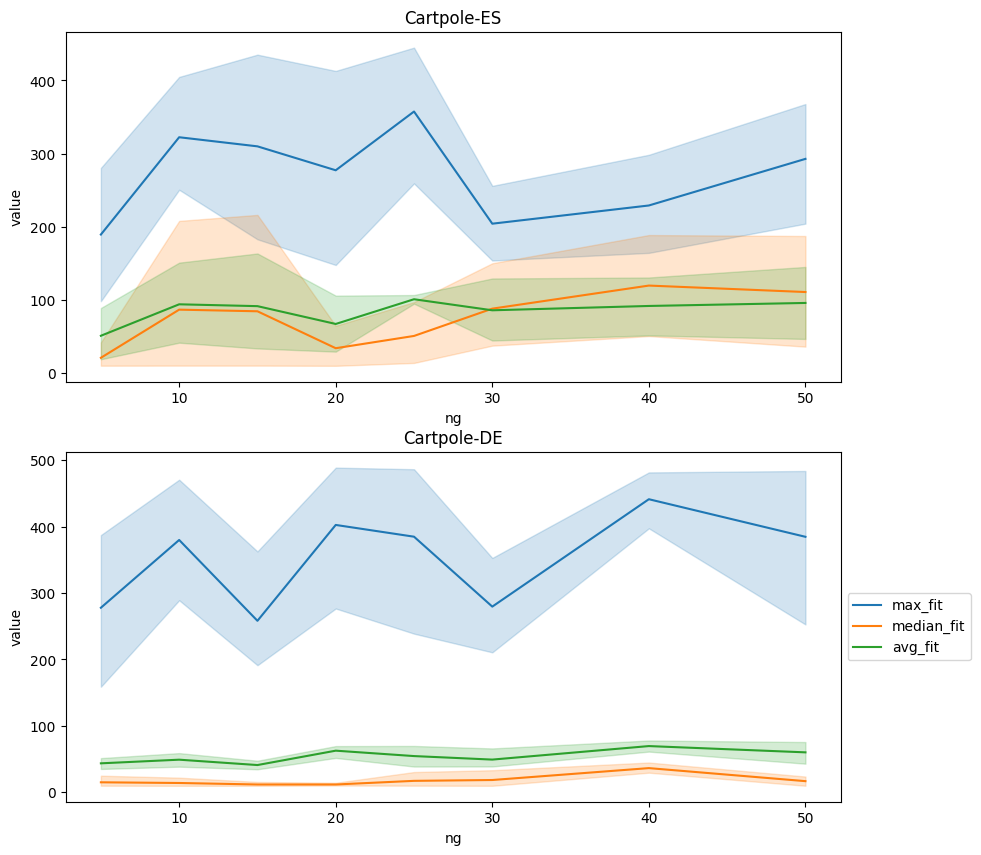

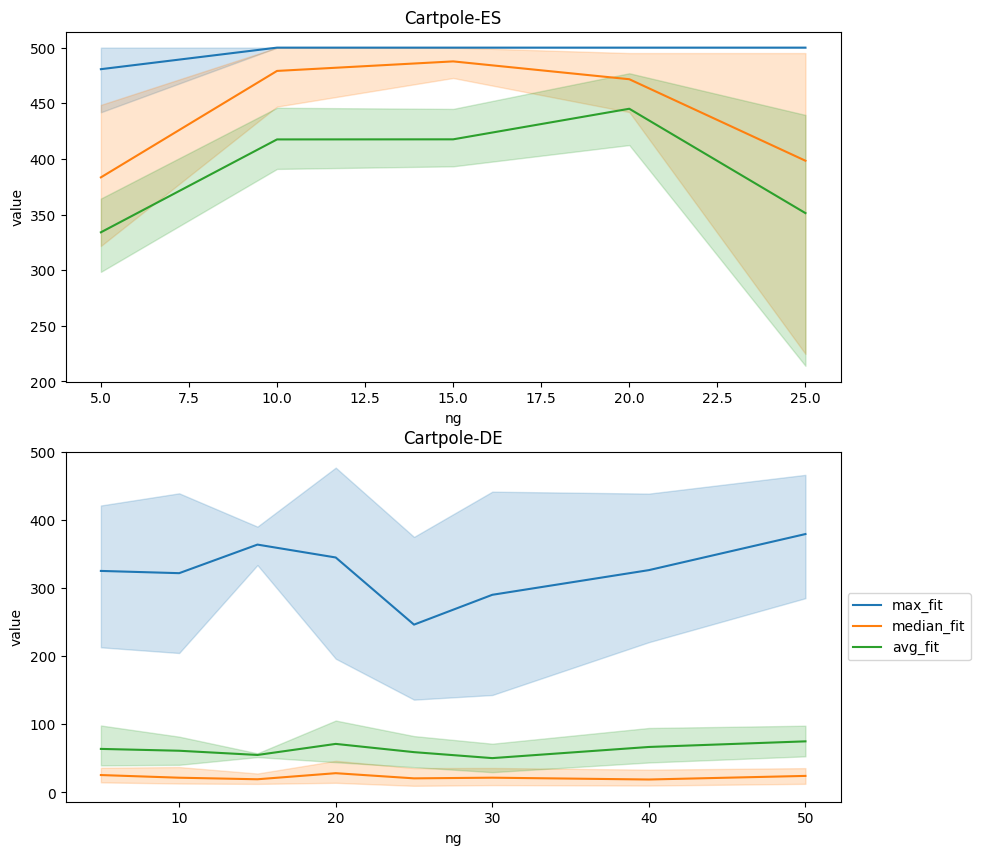

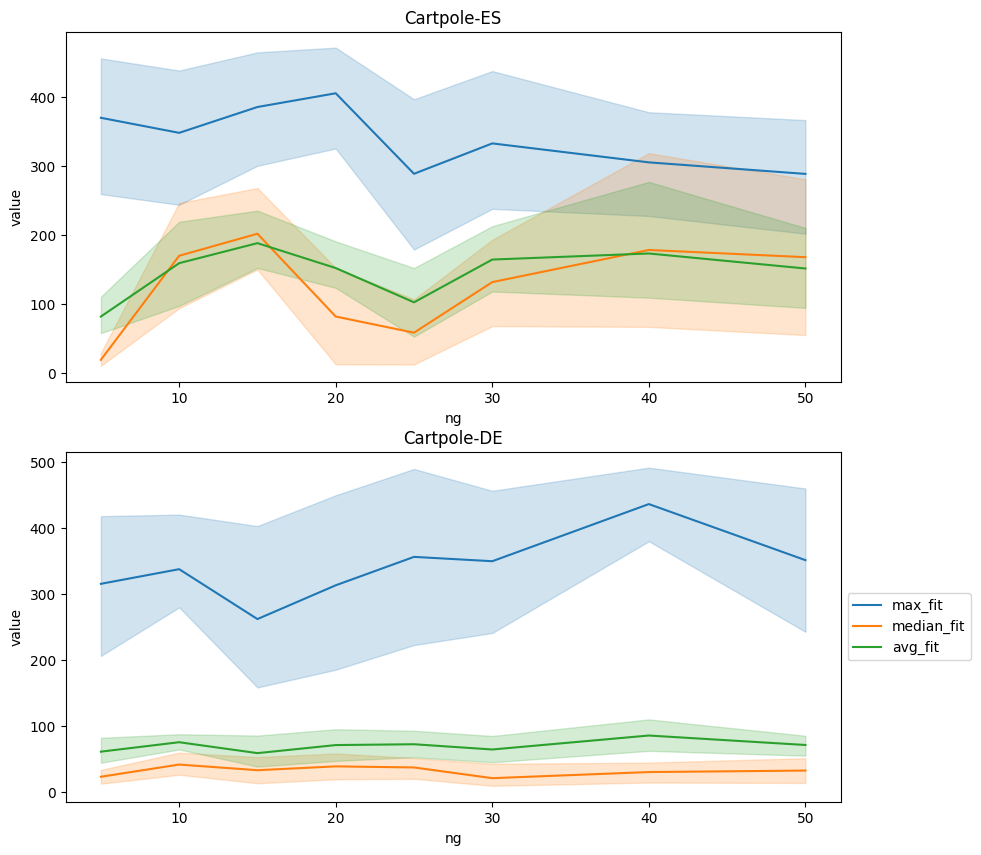

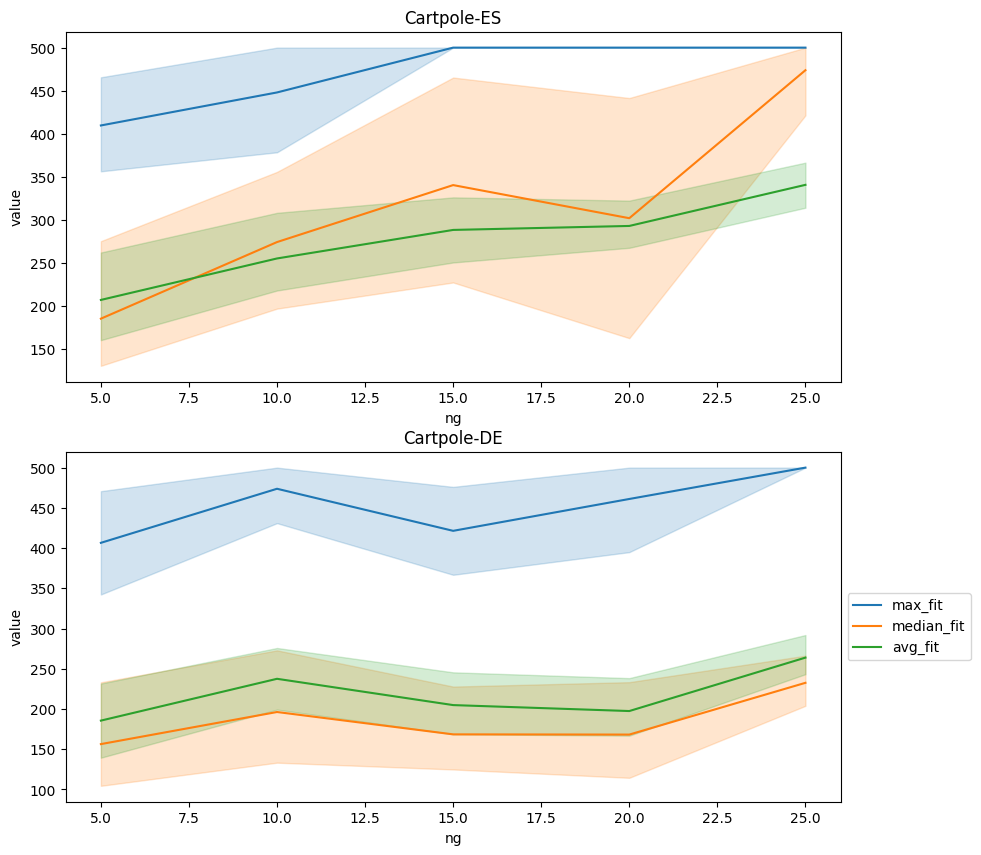

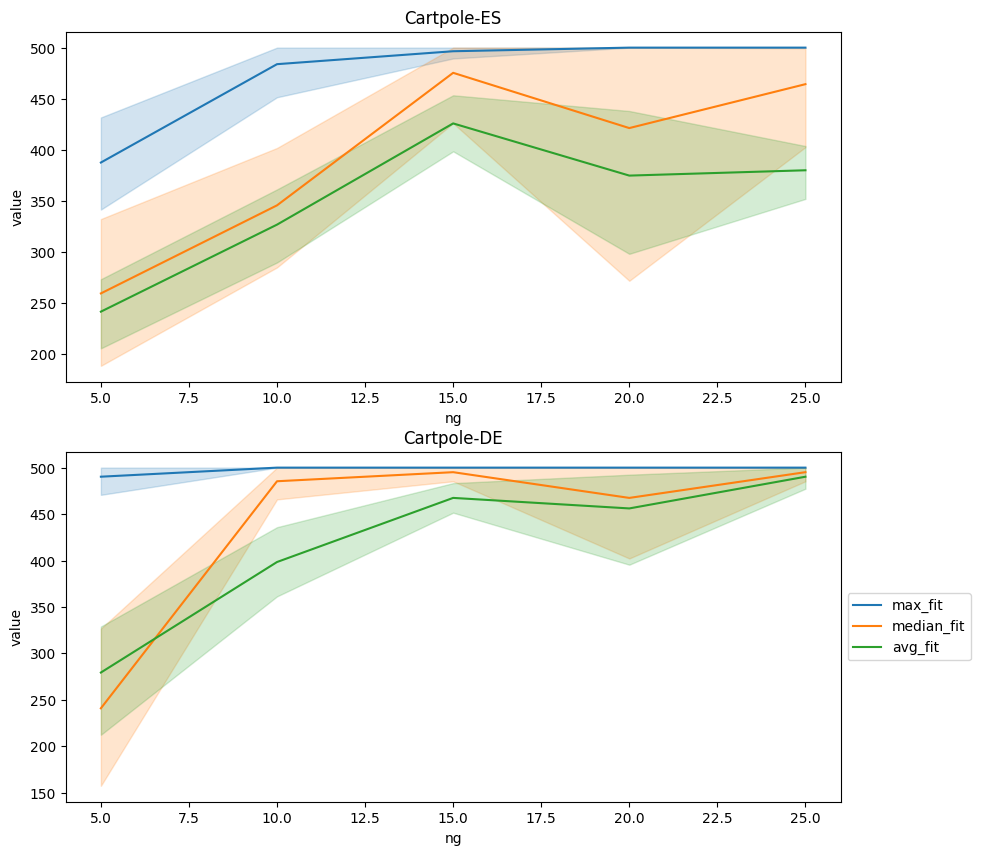

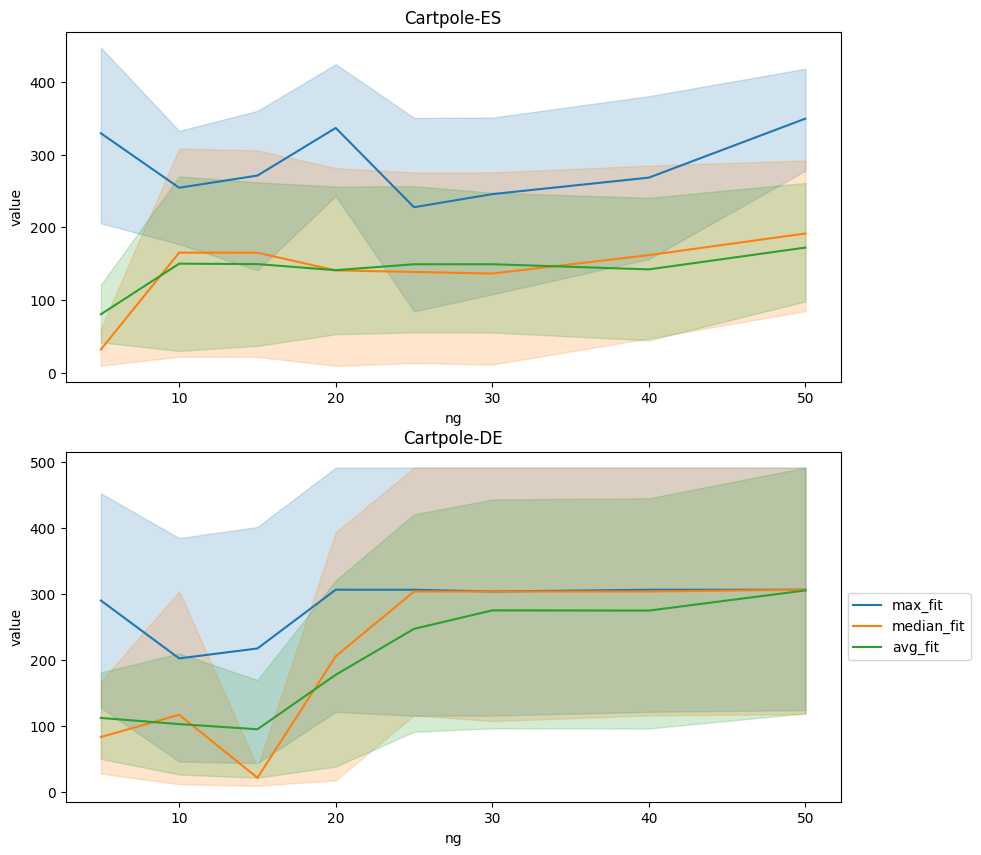

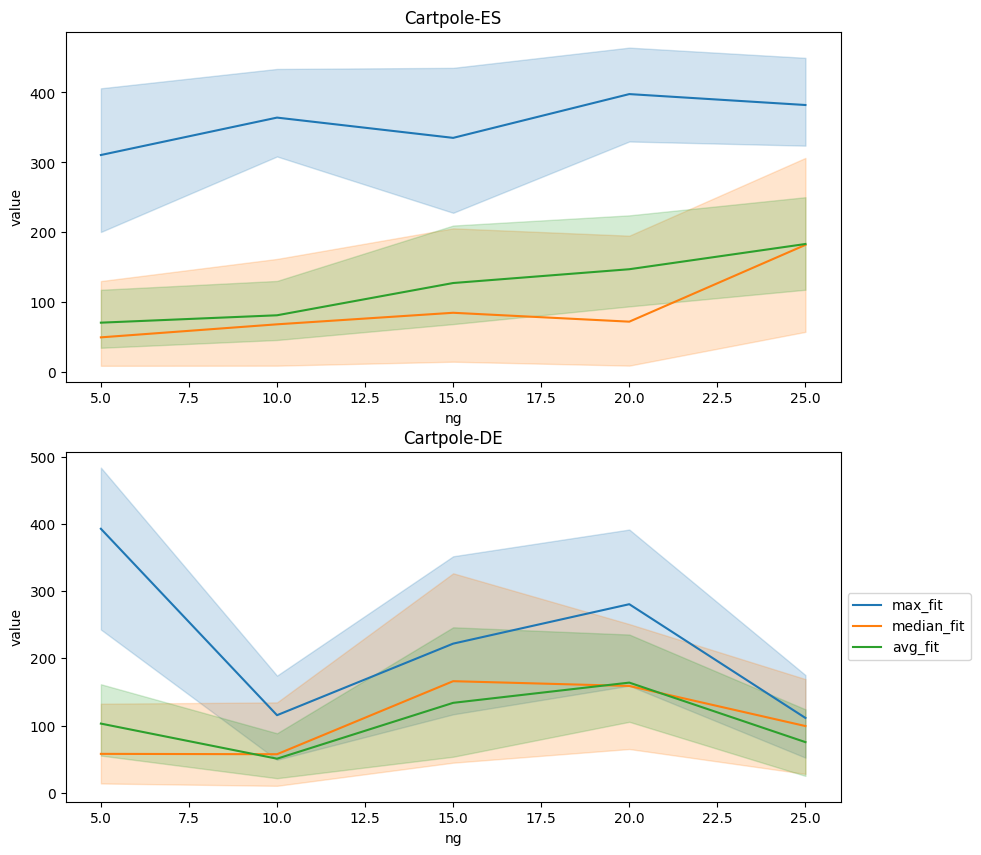

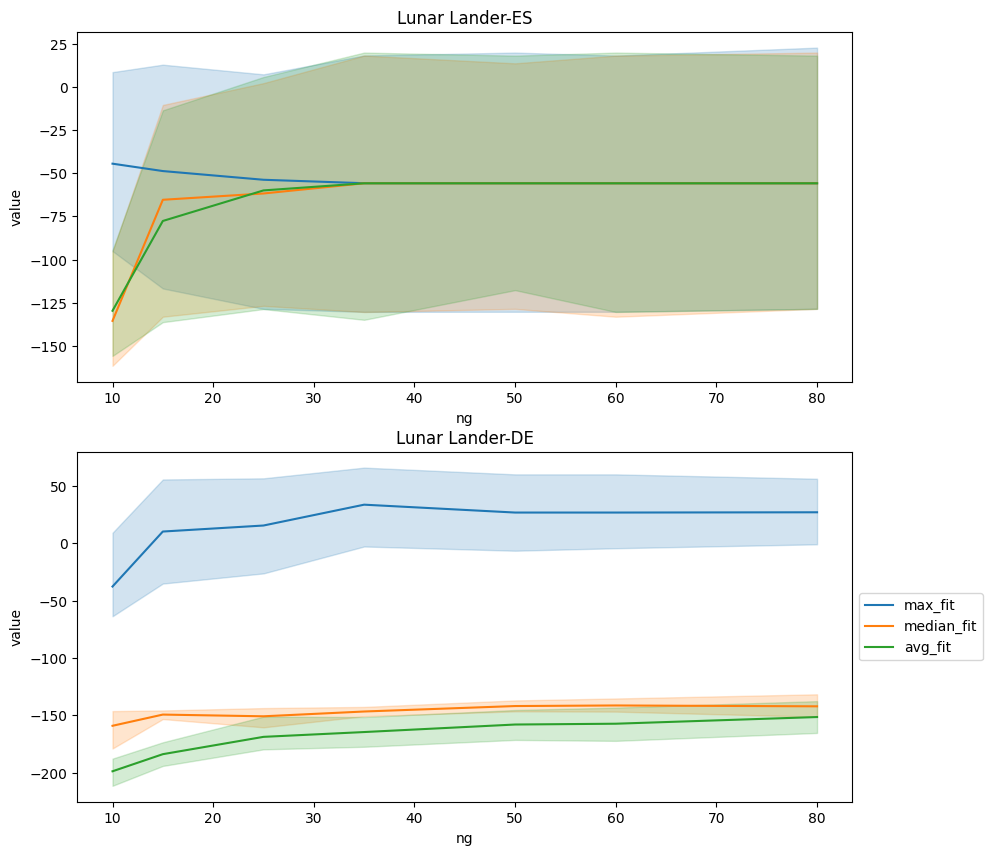

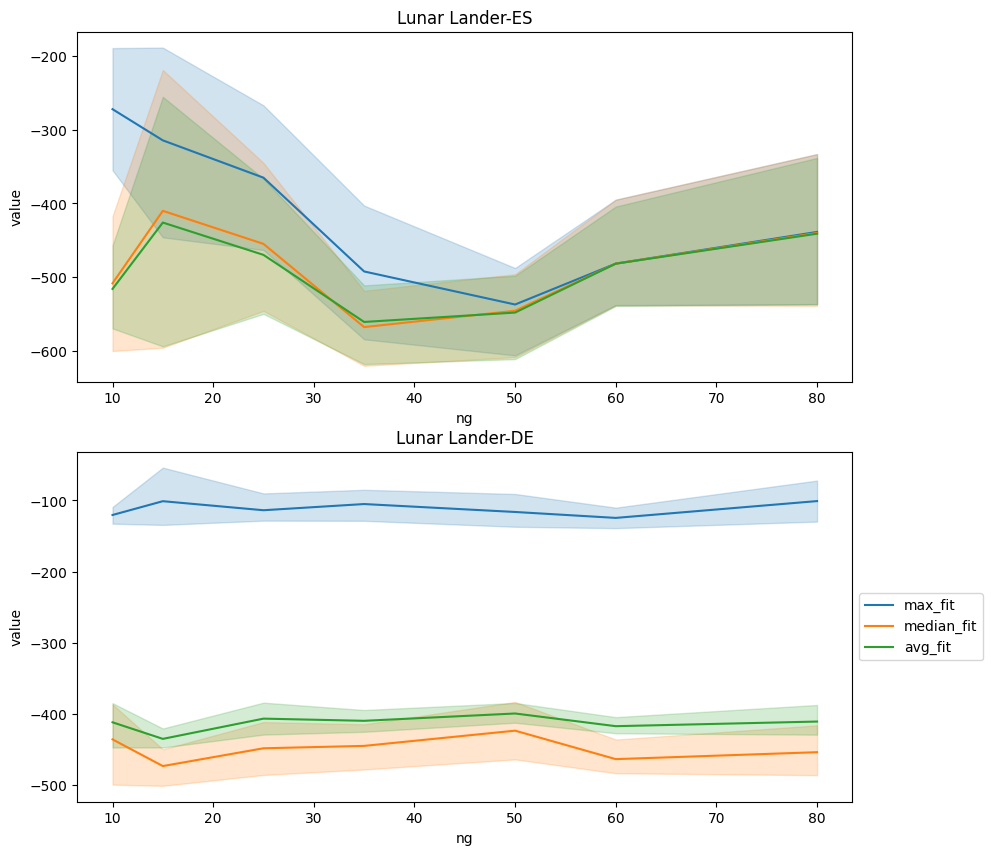

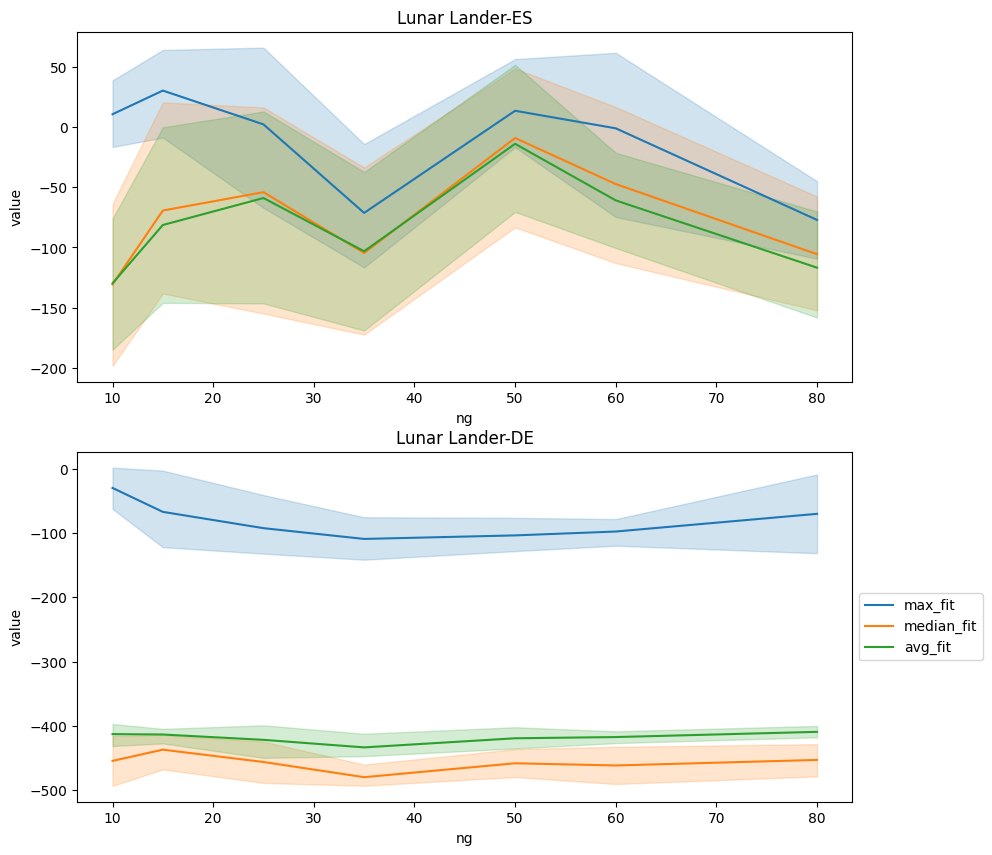

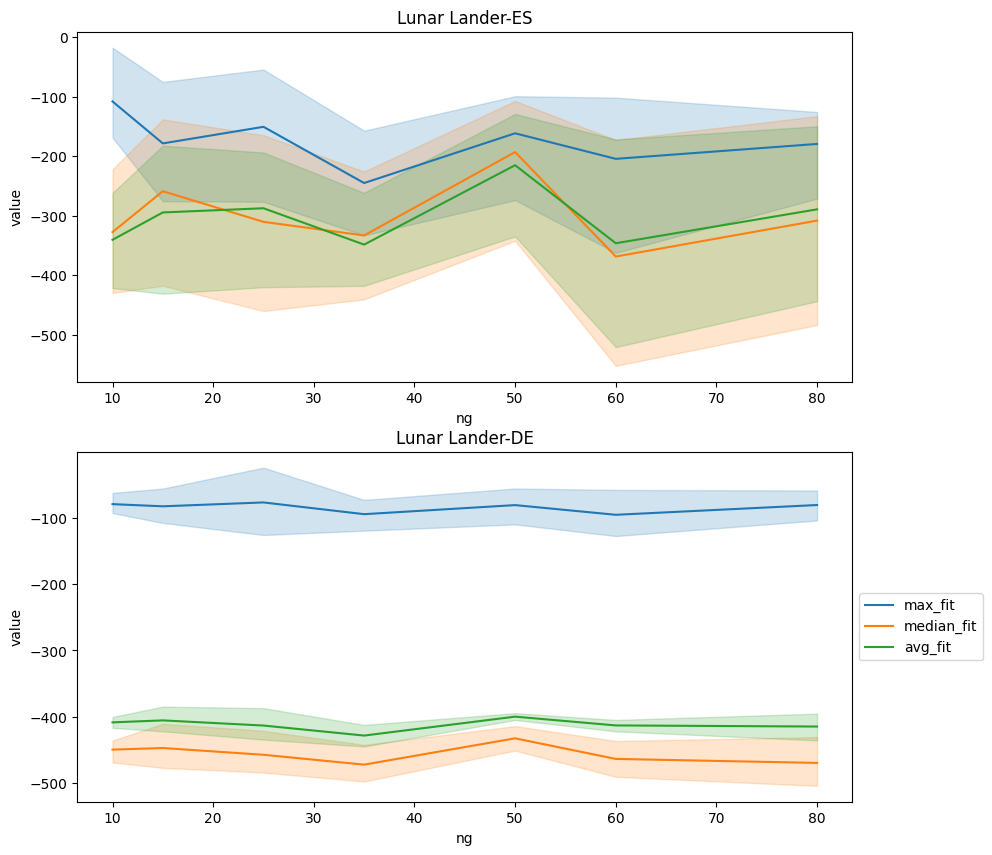

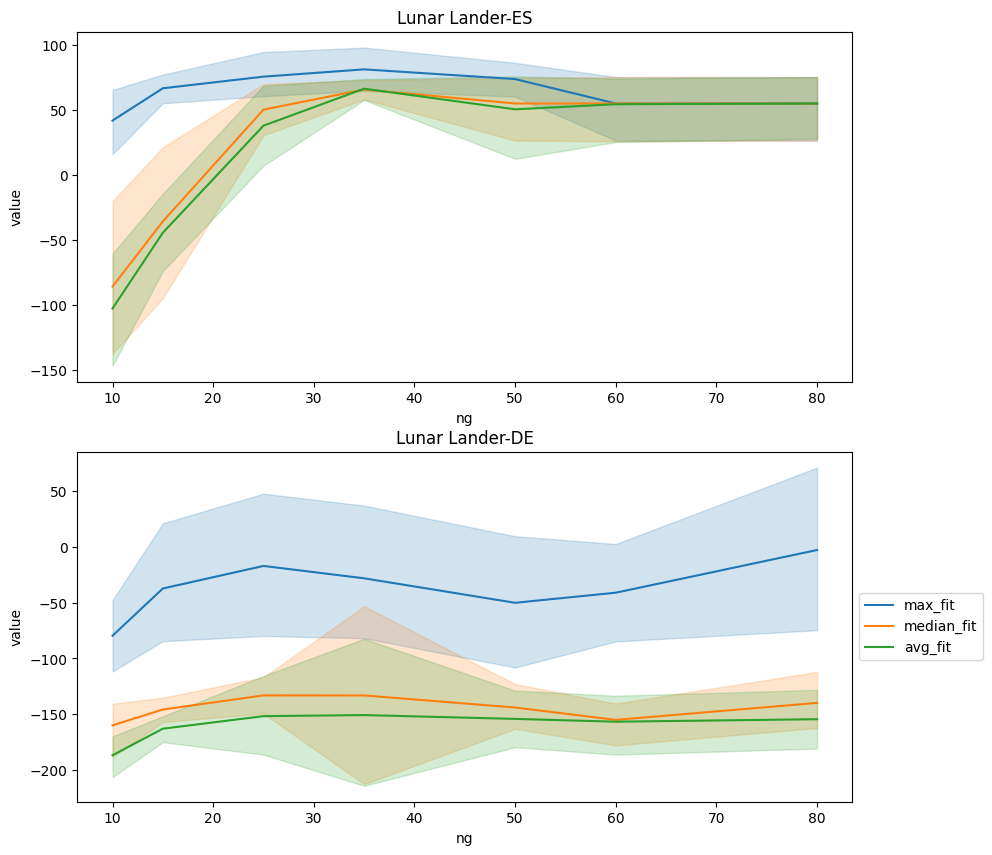

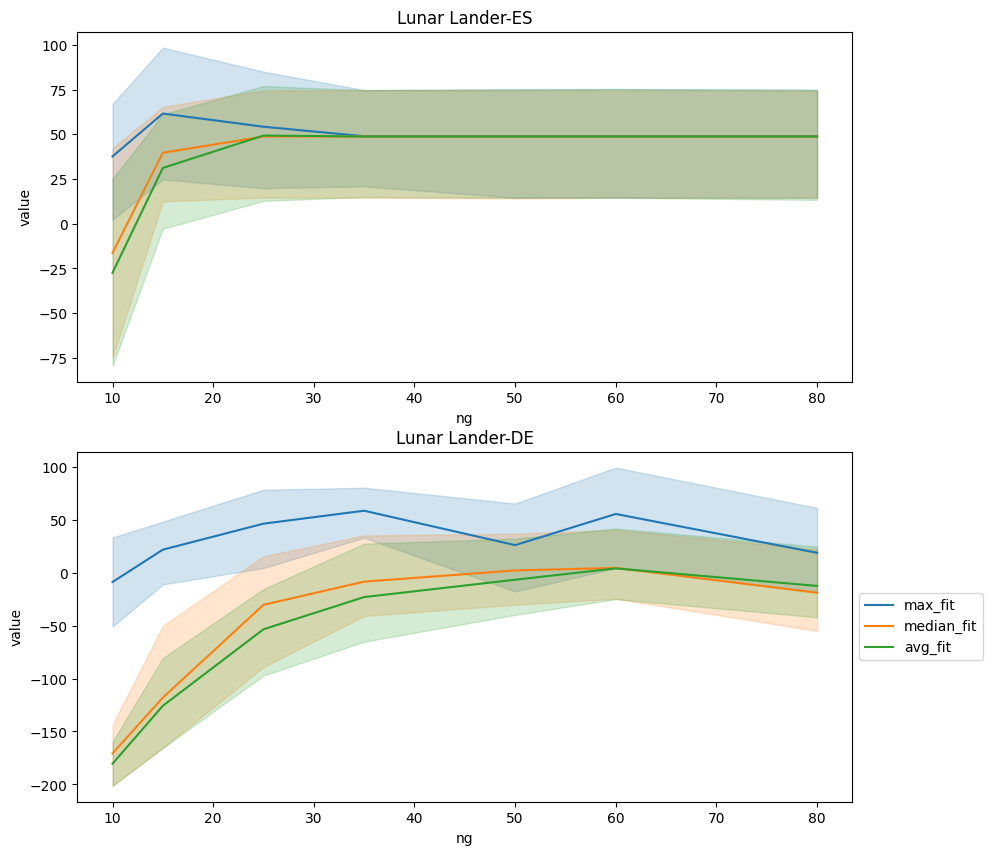

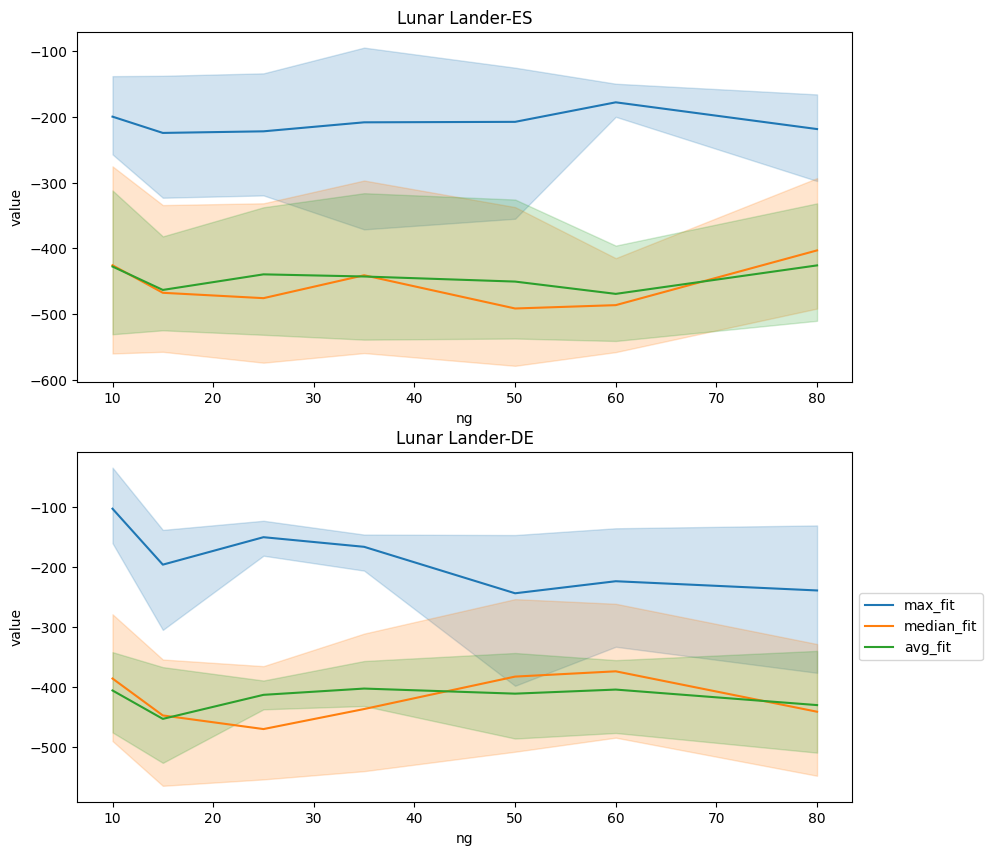

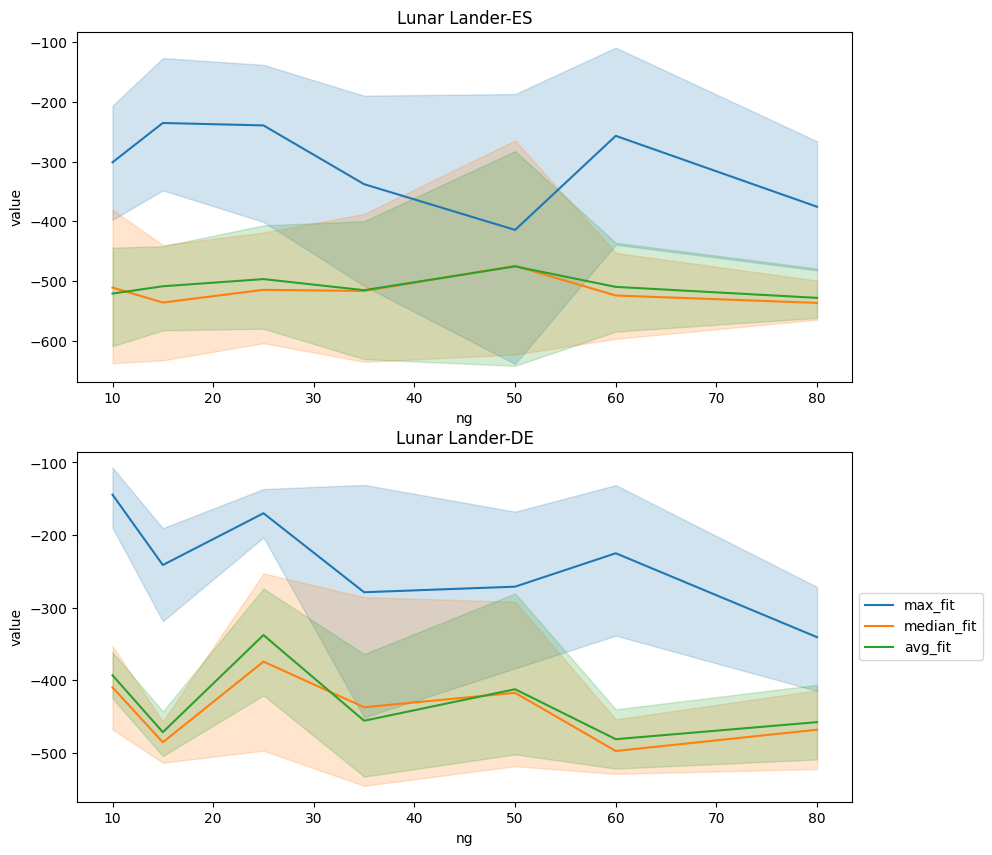

In [10]:

from libs import constants as Cst

en = "lunarlander"
cont = "elite_archiving"
alg = "diff"
env_naming = {
    "lunarlander": "Lunar Lander",
    "cartpole": "Cartpole"
}

alg_naming = {
    "lambda": "ES",
    "diff": "DE"
}
path = "../Docs/vzor-dp/img/"

for en in ["cartpole", "lunarlander"]:
    for cont in Cst.LAMBDA_CONTS:
        fig, axes = plt.subplots(2,1, figsize=(10, 10))
        for i, alg in enumerate(["lambda", "diff"]):
            ax = plot_decision_chart(en,alg,cont, axes[i])
            handles, labels = ax.get_legend_handles_labels()
            ax.legend_.remove()
            ax.set_title(f"{env_naming[en]}-{alg_naming[alg]}")
            print(cont)


        plt.legend(handles, labels, loc="center left", bbox_to_anchor=(1, 0.5))
        plt.savefig(path + f"Origin_generations_{en}_{cont}.pdf", bbox_inches="tight")

#plt.savefig(path + f"generations_{en}_{alg}_{attr}.pdf", bbox_inches="tight")

In [12]:
latex = ""
container_naming = {
    "add_novelty": "inc. fitness",
    "sub_novelty": "inc. novelty",
    "novelty": "pure novelty",
    "novelty_archiving": "novelty archive",
    "novelty_limit": "limit archive",
    "fit_archiving": "fit. archive",
    "elite_archiving": "elite archive",
    "fitness":"fitness"
}
for en in ["cartpole", "lunarlander"]:
    for cont in Cst.LAMBDA_CONTS:
        figure = f"""
            \\begin{{figure}}[H]
            \centering
            \includegraphics[width=0.9\\textwidth]{{../img/Origin_generations_{en}_{cont}}}
            \caption{{Detailed fitness/generation characteristic for {container_naming[cont]} on {env_naming[en]} env. }}
            \label{{fig:og_gen_{en}_{cont}}}
            \end{{figure}}\n
        """
        latex += figure

with open("../Docs/vzor-dp/tex/generation_apendix.tex", "w") as f:
    f.write(latex)

In [ ]:
file_content["arguments"]

{'cross_method': 'uniform',
 'l': 85,
 'm': 70,
 'mr': 0.25,
 'cr': 1.0,
 'mutation_sigma': 0.5,
 'fitness_weight': 0.6000000000000001,
 'decay': 2.0,
 'cross_uni': 0.7000000000000001}

In [ ]:
carpole_dict = {
    "sub_novelty":{
        "lambda": 20,
        "diff":40
    },
    "add_novelty":{
        "diff": 20,
        "lambda": 15
    },
    "novelty":{
        "lambda":25,
        "diff": 40
    },
    "fitness":{
        "diff": 10,
        "lambda": 15
    },
    "fit_archiving":{
        "diff": 25,
        "lambda": 35
    },
    "elite_archiving":{
        "lambda": 20,
        "diff": 10
    },
    "novelty_limit":{
        "lambda": 20,
        "diff": 20
    },
    "novelty_archiving":{
        "diff": 20,
        "lambda": 20
    }
}
lunarlander = {
    "fitness":{
        "diff": 35,
        "lambda": 25
    },
    "novelty":{
        "lambda": 10,
        "diff": 15
    },
    "fit_archiving":{
        "diff": 80,
        "lambda": 15,
    },
    "add_novelty":{
        "lambda": 15,
        "diff":15
    },
    "sub_novelty":{
        "lambda": 25,
        "diff": 25
    },
    "novelty_archiving":{
        "diff": 25,
        "lambda": 60
    },
    "elite_archiving":{
        "lambda":15,
        "diff": 60,
    },
    "novelty_limit":{
        "lambda":25,
        "diff": 25
    }
}

In [ ]:
get_decided()

array(['add_novelty.cartpole.diff', 'add_novelty.cartpole.lambda',
       'elite_archiving.lunarlander.diff',
       'elite_archiving.lunarlander.lambda',
       'fit_archiving.cartpole.diff', 'fit_archiving.cartpole.lambda',
       'fit_archiving.lunarlander.diff',
       'fit_archiving.lunarlander.lambda', 'fitness.cartpole.diff',
       'fitness.cartpole.lambda', 'fitness.lunarlander.diff',
       'fitness.lunarlander.lambda', 'novelty.cartpole.diff',
       'novelty.cartpole.lambda', 'novelty.lunarlander.diff',
       'novelty.lunarlander.lambda', 'novelty_archiving.cartpole.diff',
       'novelty_archiving.cartpole.lambda',
       'novelty_archiving.lunarlander.diff',
       'novelty_archiving.lunarlander.lambda',
       'novelty_limit.cartpole.lambda', 'novelty_limit.lunarlander.diff',
       'novelty_limit.lunarlander.lambda', 'sub_novelty.cartpole.diff',
       'sub_novelty.cartpole.lambda'], dtype='<U36')

In [ ]:
# DECIDED_NG_VALUE = 60   
# args = file_content["arguments"]
# args["ng"] = DECIDED_NG_VALUE
# save_final_hyperparameters(en, cont, alg, args)

<class 'dict'>
Just saved elite_archiving,lunarlander,diff
